# Steam Games EDA

This notebook explores the raw Steam dataset and the pricing problem. It motivates the target construction, feature choices, leakage boundaries, and market-scope decision used in the later feature engineering, modeling, and evaluation notebooks.


In [1]:
import csv

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "games.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"


## 1. Load data safely

The raw CSV header is slightly malformed: `Discount` and `DLC count` were merged into one header label, while the data rows still contain both fields. A normal `pd.read_csv()` shifts the columns, so the loader repairs the header before creating the DataFrame.


In [2]:
NUMERIC_COLS = [
    "Peak CCU",
    "Required age",
    "Price",
    "Discount",
    "DLC count",
    "Metacritic score",
    "User score",
    "Positive",
    "Negative",
    "Score rank",
    "Achievements",
    "Recommendations",
    "Average playtime forever",
    "Average playtime two weeks",
    "Median playtime forever",
    "Median playtime two weeks",
]

BOOL_COLS = ["Windows", "Mac", "Linux"]


def load_games_csv(path):
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        raw_header = next(reader)
        header = raw_header[:7] + ["Discount", "DLC count"] + raw_header[8:]

        for raw_row in reader:
            if len(raw_row) != len(header):
                raise ValueError(f"Unexpected row length {len(raw_row)}")
            rows.append(raw_row)

    df = pd.DataFrame(rows, columns=header)

    df["AppID"] = pd.to_numeric(df["AppID"], errors="coerce").astype("Int64")
    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in BOOL_COLS:
        df[col] = df[col].map({"True": True, "False": False})

    df["Release date parsed"] = pd.to_datetime(df["Release date"], format="%b %d, %Y", errors="coerce")
    df["Release year"] = df["Release date parsed"].dt.year
    df["Review count"] = df["Positive"].fillna(0) + df["Negative"].fillna(0)
    df["Positive share"] = np.where(df["Review count"] > 0, df["Positive"] / df["Review count"], np.nan)

    return df


df = load_games_csv(DATA_DIR / "games.csv")

print(f"Shape: {df.shape}")
df.head()


Shape: (122611, 40)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,,[],[],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/header.jpg?t=1699268702,,,,True,False,False,0,,0,0,0,NaN,0,0,,0,0,0,0,,,,,,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/ss_7d9504b958d0b143d053d31cb74b375daba338...,
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come into full bloom. The protagonist Yukinari Sanada has returned to his h...",['English'],[],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/496350/header.jpg?t=1725519097,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,,0,252,3,NaN,0,231,,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/496350/ss_0a5ff85870a1c2221e495b75a5c7b9e248eb324...,
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical and entrancing world of Edgar Allan Poe's ''The Raven!'' This work re...","['English', 'French', 'German', 'Russian']",[],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/1034400/header.jpg?t=1687434115,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,,0,21,3,NaN,0,0,,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,T...",https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/1034400/ss_12d8bb27a16046fe548818dcd0f5d7d0e20381...,
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' It's been three years since I've repeated such greetings. Hiyoro, who ...",['Korean'],['Korean'],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3292190/header.jpg?t=1742217574,,,yujingamesc@gmail.com,True,False,False,0,,0,0,0,NaN,19,0,The game includes the following elements. 1. General Mature Content : Revealing outfits; sexual stimulation; sexual ...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3292190/ss_87f071dbf846e7832ff49d68b0d7a8b6509bcd...,
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,"Its not just a Maze; its a Quest! Enter the captivating realm of Maze Quest, where each unexpected turn presents fre...",['English'],['English'],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3631080/2a78ae30e350862e415889f097e422855eca25b9/...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,,0,0,0,NaN,0,0,,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3631080/3c3874df57f1a1a1f544e81ee21581f8b52140b5/...,


## 2. Dataset overview

Start with the schema, data types, missing values, and duplicate checks. This separates identifier/reference columns from fields that can support a price model.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122611 non-null  Int64  
 1   Name                        122611 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  str    
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  int64  
 6   Price                       122611 non-null  float64
 7   Discount                    122611 non-null  int64  
 8   DLC count                   122611 non-null  int64  
 9   About the game              122611 non-null  str    
 10  Supported languages         122611 non-null  str    
 11  Full audio languages        122611 non-null  str    
 12  Reviews                     122611 non-null  str    
 13  Header image             

In [4]:
missing = (
    df.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing.head(15)

,missing_count,missing_pct
Score rank,122571,99.97
AppID,0,0.00
Name,0,0.00
User score,0,0.00
Positive,0,0.00
Negative,0,0.00
Achievements,0,0.00
Recommendations,0,0.00
Notes,0,0.00
Average playtime forever,0,0.00


## 3. Candidate feature groups

For a pre-release price model, the most useful columns are metadata that a developer would know before launch:

- Structured metadata: `Required age`, `Windows`, `Mac`, `Linux`, `DLC count`, `Achievements`, release timing
- Multi-label fields: `Categories`, `Genres`, `Tags`
- Developer and publisher fields as references, but not as primary features in the first model

Some columns need special care:

- High-cardinality identifiers or URLs: `AppID`, `Header image`, `Website`, `Support url`
- Sparse text fields: `Reviews`, `Notes`
- Post-release outcome variables: `Positive`, `Negative`, `Recommendations`, `Peak CCU`, playtime columns

The outcome variables are useful for a separate player-facing value model, but they would leak future information into a launch-price model.


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate AppID values:", df["AppID"].duplicated().sum())
print("Duplicate Name values:", df["Name"].duplicated().sum())

Duplicate rows: 0
Duplicate AppID values: 0
Duplicate Name values: 1156


## 4. Numeric distributions

Many numeric columns are heavily right-skewed. Log-scaled plots are more informative than raw histograms and motivate log transforms for engagement-style variables.


In [6]:
numeric_cols = [
    "Price",
    "Required age",
    "Peak CCU",
    "Positive",
    "Negative",
    "Recommendations",
    "Average playtime forever",
    "Achievements",
    "Metacritic score",
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,122611.0,4.765091,12.531030,0.0,0.55,2.24,5.24,999.98
Required age,122611.0,0.167611,1.653591,0.0,0.00,0.00,0.00,21.00
Peak CCU,122611.0,54.593324,3729.451567,0.0,0.00,0.00,0.00,1013936.00
Positive,122611.0,1044.986135,28091.729937,0.0,0.00,5.00,37.00,7642084.00
Negative,122611.0,169.197429,5374.644880,0.0,0.00,1.00,10.00,1173003.00
Recommendations,122611.0,961.824967,21878.803992,0.0,0.00,0.00,0.00,4830455.00
Average playtime forever,122611.0,208.023220,11217.684738,0.0,0.00,0.00,0.00,3429544.00
Achievements,122611.0,18.087015,141.493879,0.0,0.00,2.00,19.00,9821.00
Metacritic score,122611.0,2.564941,13.660559,0.0,0.00,0.00,0.00,97.00


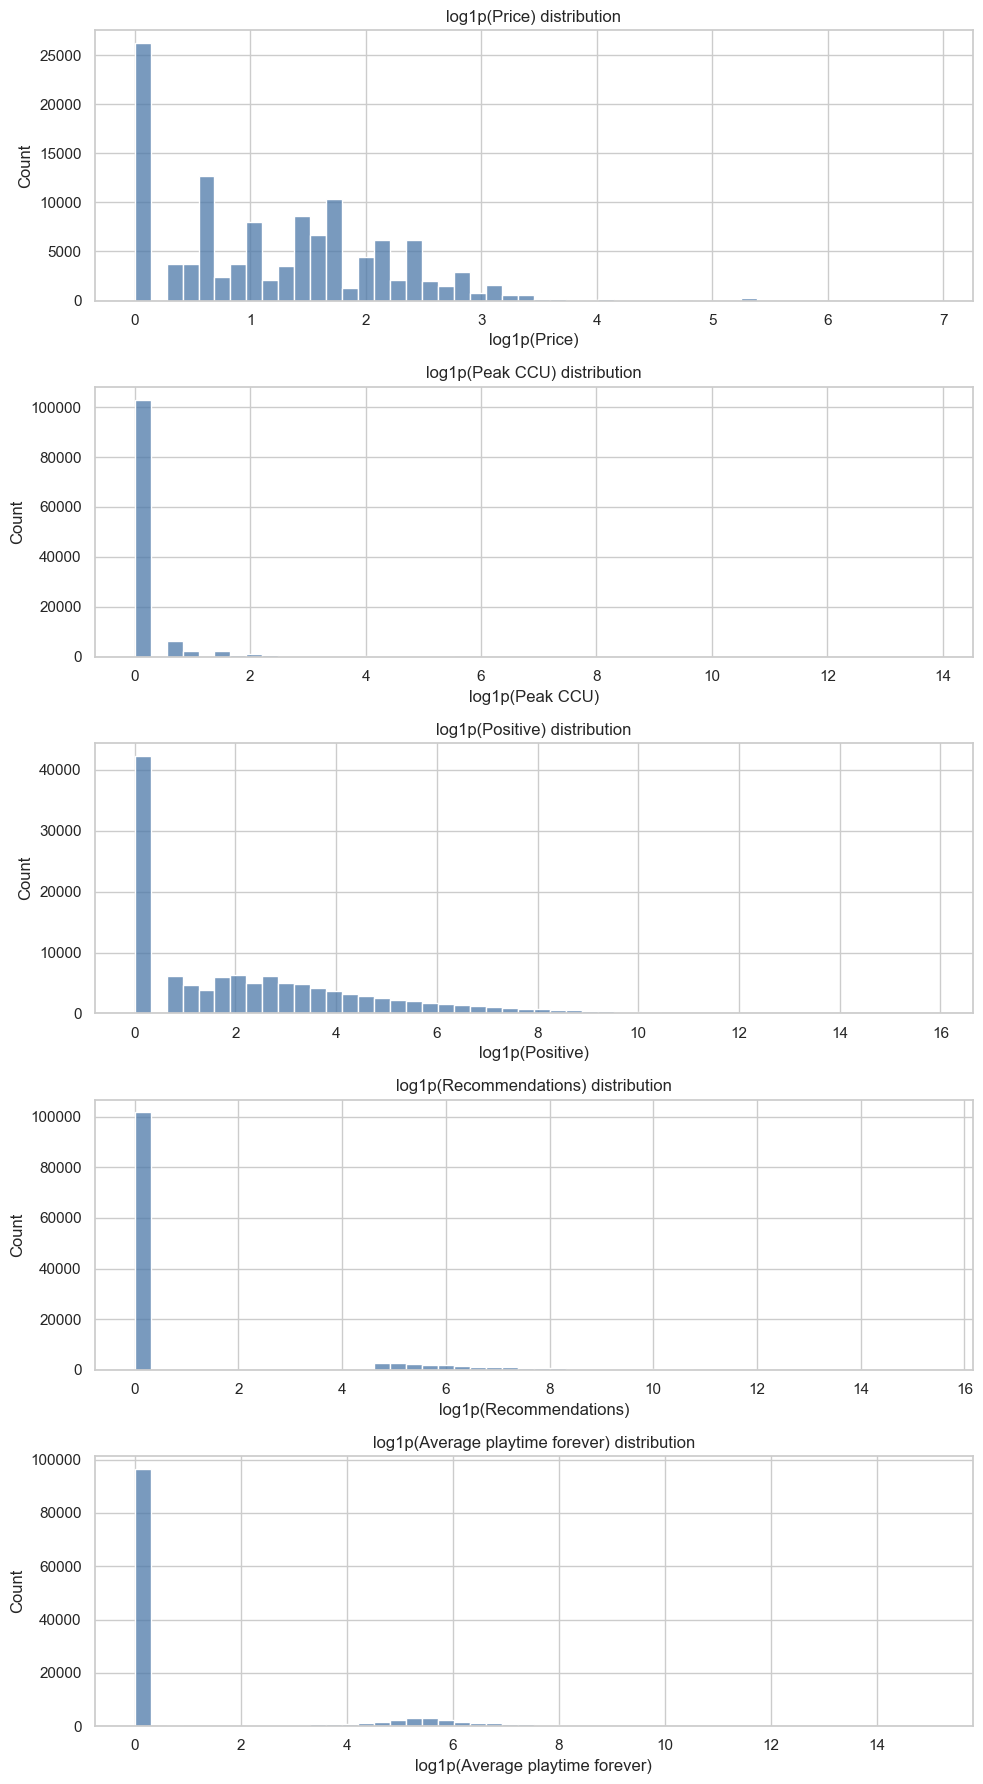

In [7]:
plot_cols = ["Price", "Peak CCU", "Positive", "Recommendations", "Average playtime forever"]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 18))

for ax, col in zip(axes, plot_cols):
    values = np.log1p(df[col].fillna(0))
    sns.histplot(values, bins=50, ax=ax, color="#4C78A8")
    ax.set_title(f"log1p({col}) distribution")
    ax.set_xlabel(f"log1p({col})")

plt.tight_layout()

In [8]:
platform_counts = df[["Windows", "Mac", "Linux"]].sum().sort_values(ascending=False)
platform_counts

Windows    122567
Mac         21292
Linux       15706
dtype: int64

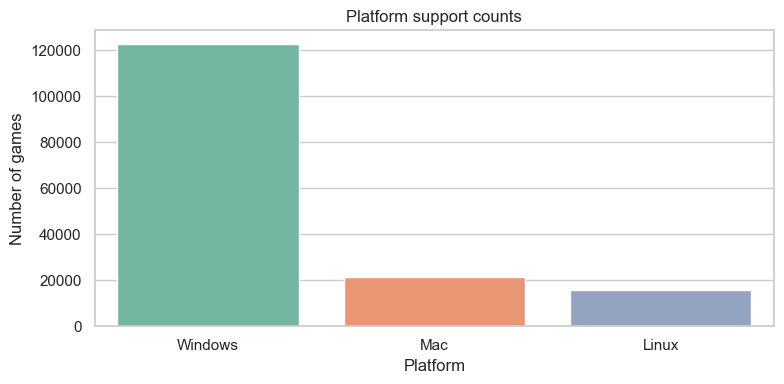

In [9]:
plt.figure(figsize=(8, 4))
sns.barplot(x=platform_counts.index, y=platform_counts.values, hue=platform_counts.index, palette="Set2", legend=False)
plt.title("Platform support counts")
plt.xlabel("Platform")
plt.ylabel("Number of games")
plt.tight_layout()

## 5. Multi-label metadata

Important pricing signal is likely hidden inside comma-separated fields such as `Genres`, `Categories`, and `Tags`. These fields will later become multi-hot encoded features.


In [10]:
def split_items(series):
    return (
        series.dropna()
        .astype(str)
        .str.split(",")
        .explode()
        .str.strip()
        .loc[lambda s: s.ne("")]
    )

In [11]:
top_genres = split_items(df["Genres"]).value_counts().head(15)
top_categories = split_items(df["Categories"]).value_counts().head(15)
top_tags = split_items(df["Tags"]).value_counts().head(20)

display(top_genres.to_frame("count"))
display(top_categories.to_frame("count"))
display(top_tags.to_frame("count"))

,count
Genres,
Indie,80630
Casual,50210
Action,46220
Adventure,45141
Simulation,24114
Strategy,22400
RPG,20972
Free To Play,12172
Early Access,11091


,count
Categories,
Single-player,108003
Family Sharing,95904
Steam Achievements,55736
Steam Cloud,30354
Full controller support,25467
Multi-player,20294
Partial Controller Support,13691
PvP,12597
Steam Trading Cards,11377


,count
Tags,
Singleplayer,50350
Indie,48552
Action,36809
Casual,36564
Adventure,35196
2D,26792
3D,17996
Simulation,17893
Strategy,17848


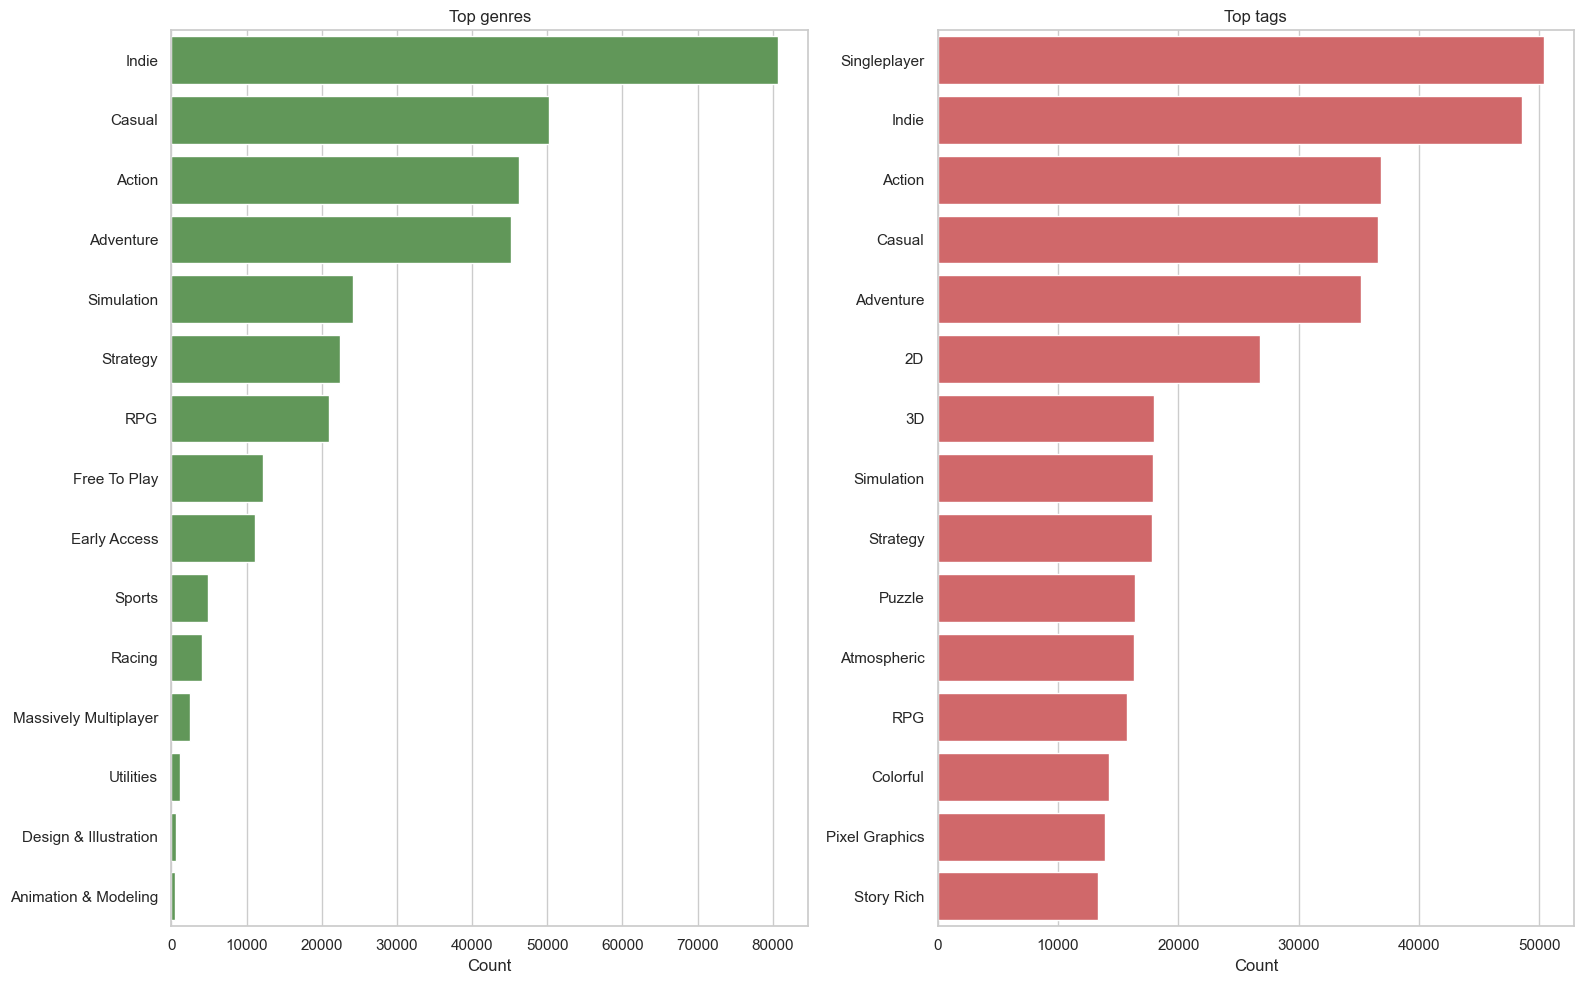

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], color="#59A14F")
axes[0].set_title("Top genres")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

sns.barplot(x=top_tags.values[:15], y=top_tags.index[:15], ax=axes[1], color="#E15759")
axes[1].set_title("Top tags")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()

## 6. Release dates

Release dates describe how the market changes over time and provide release-year and release-age features for modeling.


In [13]:
print("Parsed release dates:", df["Release date parsed"].notna().sum())
print("Missing parsed dates:", df["Release date parsed"].isna().sum())
df[["Release date", "Release date parsed", "Release year"]].head()


Parsed release dates: 122611
Missing parsed dates: 0


,Release date,Release date parsed,Release year
0,"Aug 1, 2023",2023-08-01,2023
1,"Jul 29, 2016",2016-07-29,2016
2,"May 6, 2019",2019-05-06,2019
3,"Oct 31, 2024",2024-10-31,2024
4,"Apr 24, 2025",2025-04-24,2025


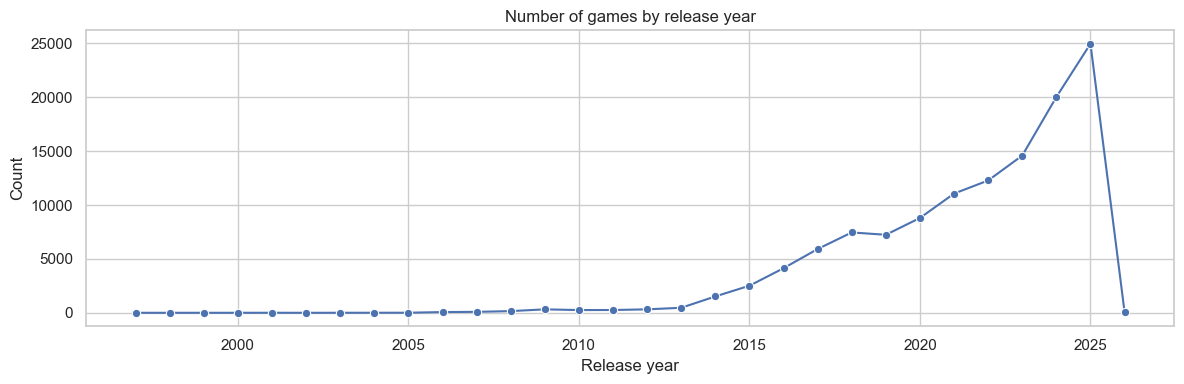

In [14]:
release_year_counts = df["Release year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.lineplot(x=release_year_counts.index, y=release_year_counts.values, marker="o")
plt.title("Number of games by release year")
plt.xlabel("Release year")
plt.ylabel("Count")
plt.tight_layout()

## 7. Numeric relationships and leakage scan

This correlation view is not model selection yet. It helps identify redundant variables and outcome-heavy fields that should be excluded from the pre-release model.


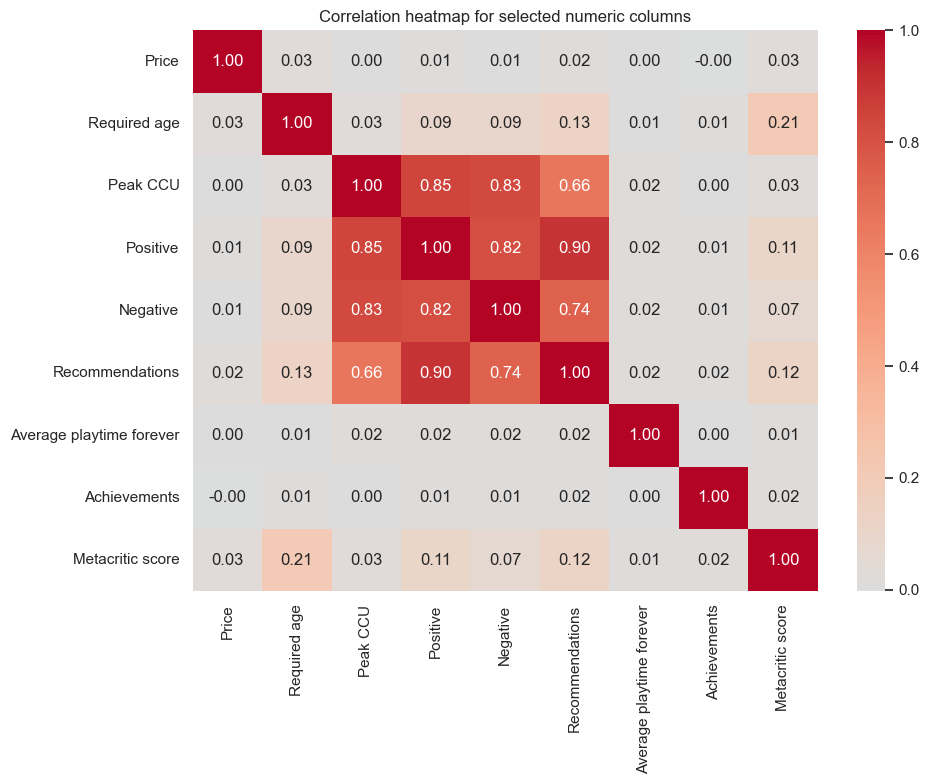

In [15]:
corr_cols = [
    "Price",
    "Required age",
    "Peak CCU",
    "Positive",
    "Negative",
    "Recommendations",
    "Average playtime forever",
    "Achievements",
    "Metacritic score",
]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap for selected numeric columns")
plt.tight_layout()

## 8. General EDA takeaways

The dataset is large enough for price modeling, but it contains a wide range of games from high-traction releases to nearly invisible titles. The feature strategy should therefore:

- use `Genres`, `Tags`, and `Categories` as central metadata features;
- keep structured pre-release fields such as platforms, age rating, DLC count, achievements, and release year;
- log-transform highly skewed count variables where they are used;
- separate post-release engagement and review variables from launch-price features;
- audit market scope later, because very low-traction games may weaken the price signal.


## 9. Pricing-specific EDA

The following sections audit the price target, discount handling, feature-price relationships, and leakage risks that directly affect the modeling design.



## 10. Price target audit

Before modeling, check whether `Price` behaves like a usable target. The key questions are how many games are free, how skewed paid prices are, and whether there are strange outliers or placeholder values.



In [3]:
price_summary = pd.Series({
    "total_games": len(df),
    "missing_price": df["Price"].isna().sum(),
    "free_games": df["Price"].eq(0).sum(),
    "paid_games": df["Price"].gt(0).sum(),
    "negative_prices": df["Price"].lt(0).sum(),
})
price_summary.to_frame("count")

,count
total_games,122611
missing_price,0
free_games,26206
paid_games,96405
negative_prices,0


In [4]:
paid = df[df["Price"] > 0].copy()

paid["Price"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("price")

,price
count,96405.000000
mean,6.060397
std,13.851424
min,0.490000
1%,0.490000
5%,0.590000
10%,0.790000
25%,1.490000
50%,3.490000
75%,6.990000


In [5]:
common_prices = (
    paid["Price"]
    .round(2)
    .value_counts()
    .head(25)
    .rename_axis("price")
    .reset_index(name="game_count")
)
common_prices["pct_of_paid"] = (common_prices["game_count"] / len(paid) * 100).round(2)
common_prices

,price,game_count,pct_of_paid
0,0.99,8914,9.25
1,4.99,8102,8.40
2,1.99,6640,6.89
3,2.99,6344,6.58
4,9.99,4641,4.81
5,3.99,4561,4.73
6,0.49,3642,3.78
7,5.99,3122,3.24
8,2.49,2273,2.36
9,7.99,2178,2.26


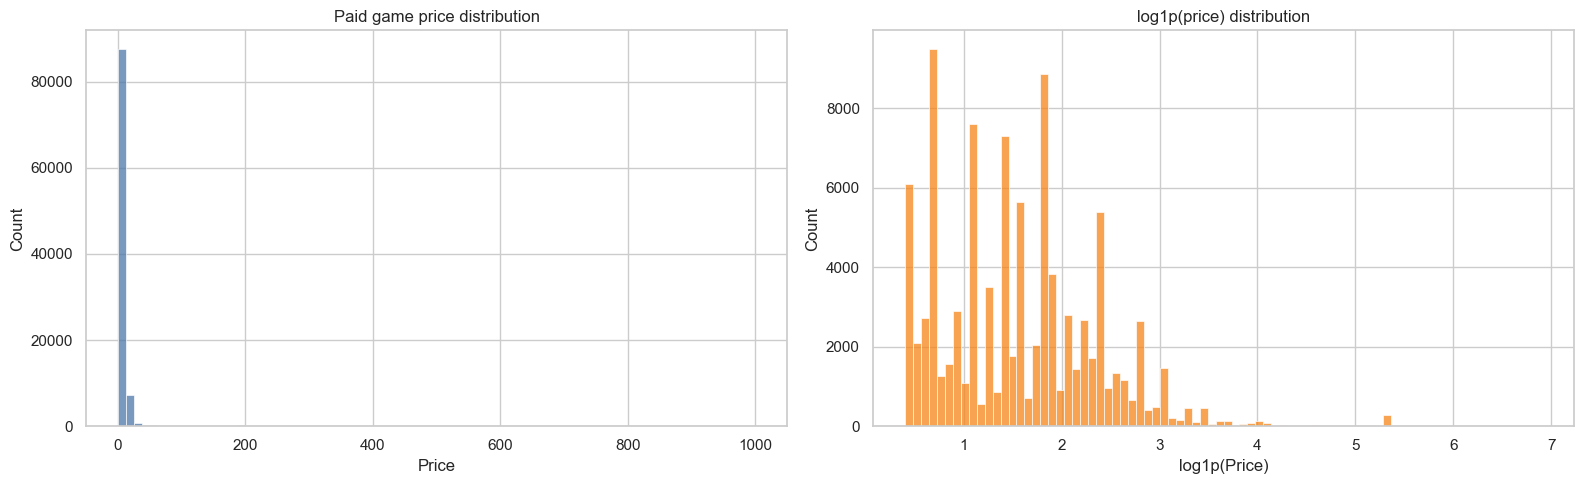

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(paid["Price"], bins=80, ax=axes[0], color="#4C78A8")
axes[0].set_title("Paid game price distribution")
axes[0].set_xlabel("Price")

sns.histplot(np.log1p(paid["Price"]), bins=80, ax=axes[1], color="#F58518")
axes[1].set_title("log1p(price) distribution")
axes[1].set_xlabel("log1p(Price)")

plt.tight_layout()

In [7]:
paid.sort_values("Price", ascending=False)[
    ["AppID", "Name", "Price", "Discount", "Genres", "Tags", "Release year", "Recommendations", "Review count"]
].head(25)

,AppID,Name,Price,Discount,Genres,Tags,Release year,Recommendations,Review count
41088,2504210,The Leverage Game Business Edition,999.98,0,"Indie,Simulation",,2023,0,0
68275,2499620,The Leverage Game,999.98,0,"Indie,Simulation","Board Game,Turn-Based Tactics,Simulation,Education,Economy,PvP,Tabletop,2D,Cute,Indie,Logic,Singleplayer,Multiplayer,Hentai",2023,0,1
34463,1200520,Ascent Free-Roaming VR Experience,999.00,0,Action,"Action,Hentai,Nudity,Sexual Content,LGBTQ+,VR,NSFW,Free to Play,Dating Sim,Anime,Horror,Psychological Horror,Multiplayer,Cute,Arena Shoo...",2019,0,7
31935,3013840,True Love,500.00,0,"Action,Adventure,Casual,Indie","Casual,Action-Adventure,Visual Novel,Dating Sim,Walking Simulator,Exploration,Hidden Object,3D,First-Person,Realistic,Cute,Third Person,...",2024,0,4
77652,1105450,Aartform Curvy 3D 4.0,299.99,0,"Animation & Modeling,Design & Illustration","Design & Illustration,Animation & Modeling,3D",2020,0,12
85479,253670,Aartform Curvy 3D 3.0,299.90,0,Animation & Modeling,Animation & Modeling,2013,0,45
102212,502570,Houdini Indie,269.99,0,"Animation & Modeling,Design & Illustration,Video Production,Game Development","Animation & Modeling,Game Development,3D,Design & Illustration,Indie,Video Production,Procedural Generation,Psychological Horror",2018,235,251
63331,2663780,Hidden World 6 Top-Down 3D,199.99,0,"Action,Adventure,Casual,Indie,Racing,RPG,Simulation,Sports,Strategy",,2023,0,0
78623,3471100,How Much Items - Plants,199.99,0,"Action,Adventure,Casual,Indie,Racing,RPG,Simulation,Sports,Strategy",,2025,0,0
92042,4187570,Nitro Drive,199.99,0,"Action,Adventure",,2025,0,0


## 11. Discount handling

The model should learn market-aligned list price, not temporary sale price. Discounted rows can still be useful if the original list price is reconstructed from the current sale price and discount percentage.



In [8]:
discount_summary = pd.Series({
    "missing_discount": df["Discount"].isna().sum(),
    "discount_zero": df["Discount"].eq(0).sum(),
    "discount_positive": df["Discount"].gt(0).sum(),
    "discount_negative": df["Discount"].lt(0).sum(),
})
discount_summary.to_frame("count")

,count
missing_discount,0
discount_zero,81930
discount_positive,40681
discount_negative,0


In [9]:
discounted = paid[paid["Discount"] > 0].copy()

print(f"Discounted paid games: {len(discounted):,} / {len(paid):,} ({len(discounted) / len(paid) * 100:.2f}%)")
display(discounted["Discount"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("discount"))

discounted.sort_values(["Discount", "Price"], ascending=False)[
    ["AppID", "Name", "Price", "Discount", "Genres", "Release year"]
].head(25)

Discounted paid games: 40,642 / 96,405 (42.16%)


,discount
count,40642.000000
mean,55.312583
std,21.571579
min,10.000000
25%,40.000000
50%,51.000000
75%,75.000000
90%,84.000000
95%,90.000000
99%,91.000000


,AppID,Name,Price,Discount,Genres,Release year
29407,1200580,One Gun Guy,0.69,100,"Action,Indie",2022
117893,460960,The Deed: Dynasty,0.59,100,"Adventure,Indie,RPG",2016
69662,3230900,Hidden Storehouse Top-Down 3D,199.99,95,"Action,Adventure,Casual,Indie,Strategy",2024
97762,3822960,Zekertune,30.76,95,Casual,2025
75989,1368670,Beach Volleyball Competition,14.50,95,"Action,Simulation,Sports",2020
11201,2085510,Fly Fly Tuk Tuk,9.99,95,"Action,Indie,Racing,Simulation,Sports",2022
15383,2363810,Long Truck Simulator,9.99,95,"Adventure,Indie,Racing,Simulation,Sports",2023
25406,2247790,Snake Robot,9.99,95,"Adventure,Casual,Indie,Simulation,Sports",2023
35135,2471600,Impossible Stunts,9.99,95,"Action,Adventure,Casual,Indie,Racing,Simulation",2023
41123,2203480,Reach the Moon!,9.99,95,"Adventure,Casual,Indie,Simulation,Strategy",2023


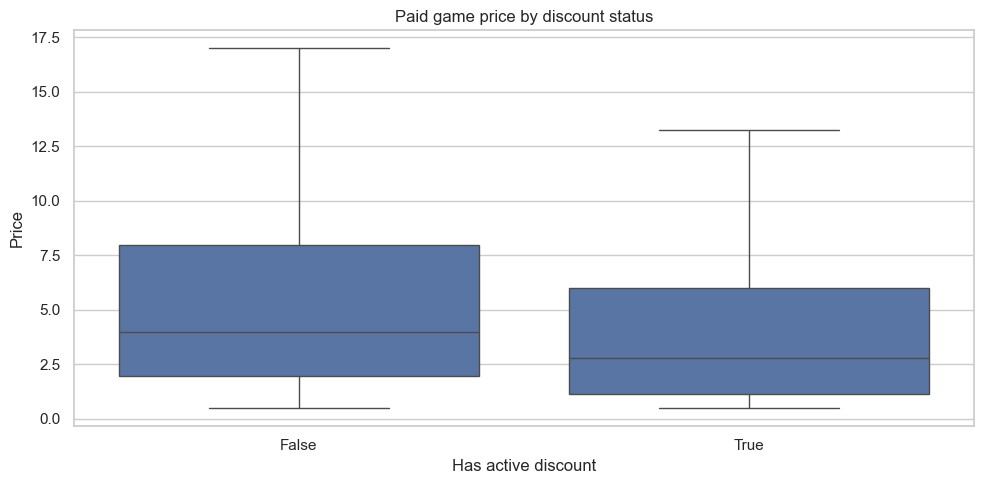

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=paid.assign(has_discount=paid["Discount"].gt(0)), x="has_discount", y="Price", showfliers=False)
plt.title("Paid game price by discount status")
plt.xlabel("Has active discount")
plt.ylabel("Price")
plt.tight_layout()

## 12. Pre-release feature-price relationships

These checks show which pre-release metadata fields plausibly explain price differences and should be carried into feature engineering.



In [11]:
analysis_df = paid[paid["Discount"].fillna(0).eq(0)].copy()
print(f"Paid, non-discounted analysis rows: {len(analysis_df):,}")
analysis_df[["Price", "Required age", "DLC count", "Achievements", "Release year"]].describe().T

Paid, non-discounted analysis rows: 55,763


,count,mean,std,min,25%,50%,75%,max
Price,55763.0,7.140587,17.398376,0.49,1.99,3.99,7.99,999.98
Required age,55763.0,0.111974,1.343079,0.00,0.00,0.00,0.00,21.00
DLC count,55763.0,0.279182,7.100153,0.00,0.00,0.00,0.00,967.00
Achievements,55763.0,15.887381,121.456811,0.00,0.00,1.00,17.00,5394.00
Release year,55763.0,2021.427398,3.176048,2000.00,2019.00,2022.00,2024.00,2026.00


In [12]:
def price_by_multilabel(df, column, min_count=200, top_n=25):
    exploded = (
        df[["Price", column]]
        .dropna(subset=[column])
        .assign(item=lambda x: x[column].astype(str).str.split(","))
        .explode("item")
    )
    exploded["item"] = exploded["item"].str.strip()
    exploded = exploded[exploded["item"].ne("")]

    summary = (
        exploded.groupby("item")["Price"]
        .agg(game_count="size", median_price="median", mean_price="mean")
        .query("game_count >= @min_count")
        .sort_values("median_price", ascending=False)
        .head(top_n)
    )
    return summary


In [13]:
genre_price = price_by_multilabel(analysis_df, "Genres", min_count=200, top_n=25)
genre_price

,game_count,median_price,mean_price
item,,,
Animation & Modeling,202,9.49,23.685495
Design & Illustration,279,8.99,18.196416
Early Access,6809,6.39,8.723958
Massively Multiplayer,699,4.99,10.777024
RPG,9603,4.99,10.020863
Simulation,11584,4.99,10.448783
Sports,2579,4.99,17.452369
Strategy,11091,4.99,9.451236
Utilities,528,4.99,11.138277


In [14]:
tag_price = price_by_multilabel(analysis_df, "Tags", min_count=300, top_n=30)
tag_price

,game_count,median_price,mean_price
item,,,
Colony Sim,303,7.99,15.657987
Moddable,333,7.39,10.318649
6DOF,357,6.99,9.446555
VR,3260,6.99,9.552420
Early Access,6096,6.39,9.007070
Grand Strategy,365,6.24,13.225123
Crafting,1438,5.99,9.990438
Building,1765,5.99,10.074782
Turn-Based,776,5.99,8.536959


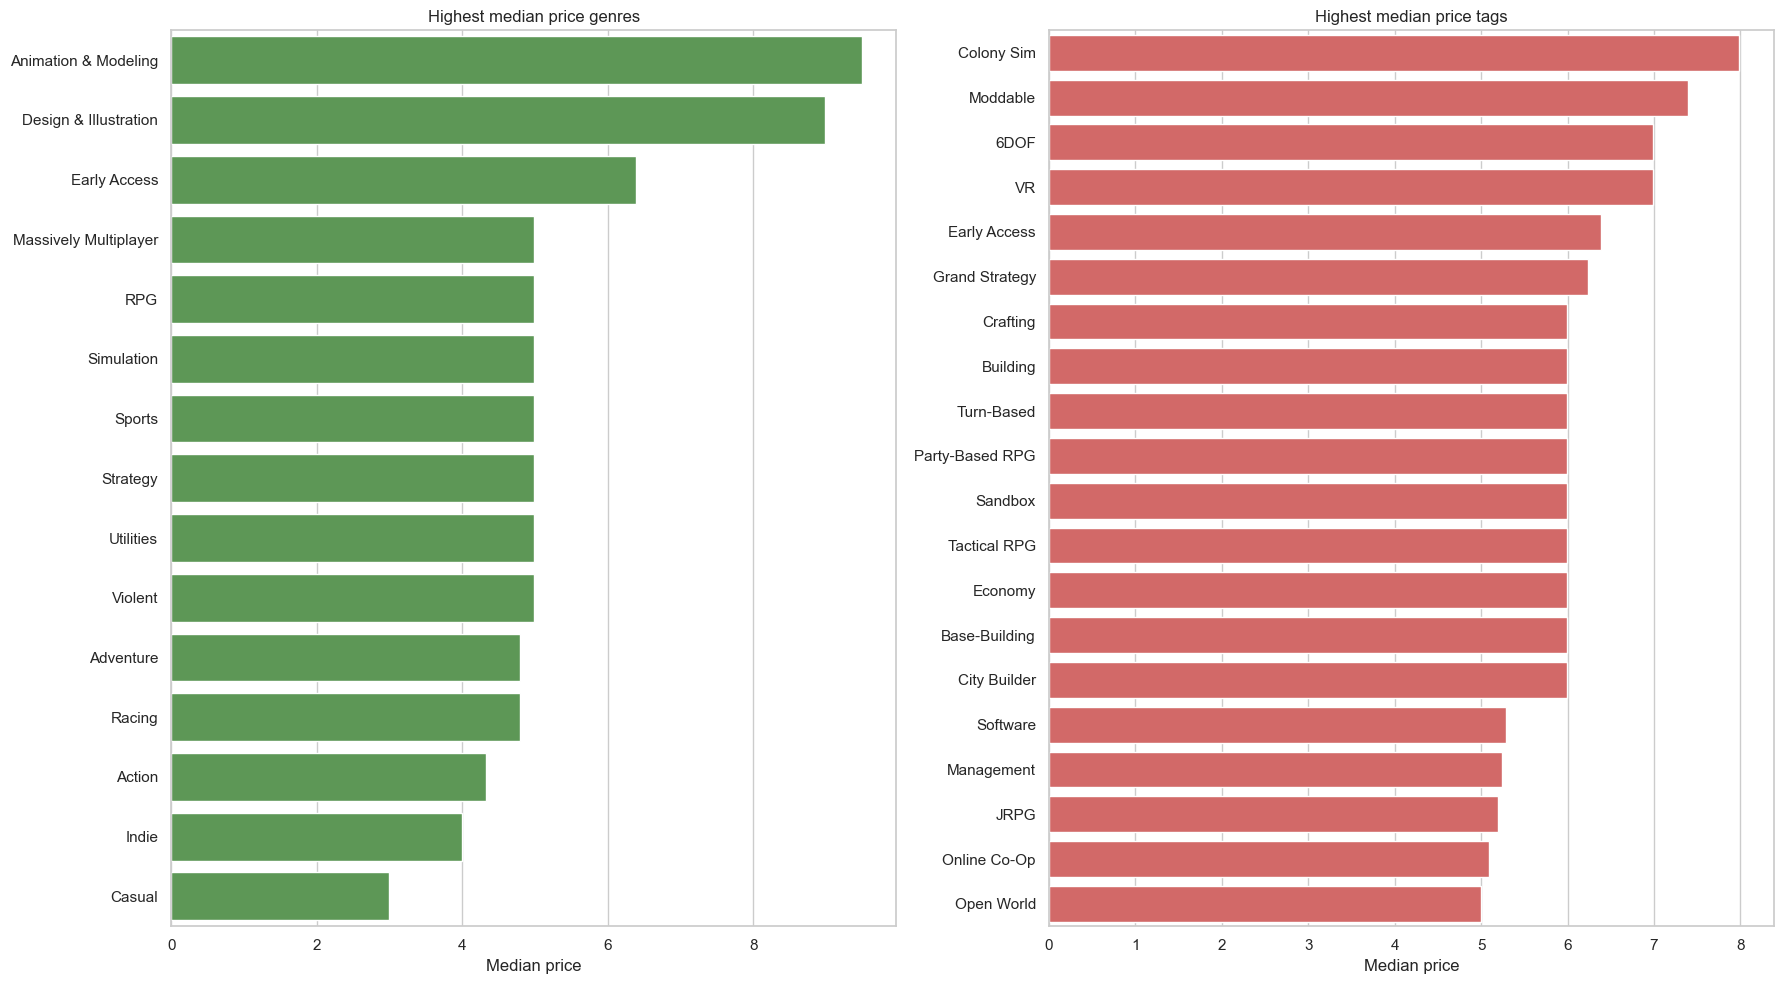

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

sns.barplot(data=genre_price.reset_index(), x="median_price", y="item", ax=axes[0], color="#54A24B")
axes[0].set_title("Highest median price genres")
axes[0].set_xlabel("Median price")
axes[0].set_ylabel("")

sns.barplot(data=tag_price.head(20).reset_index(), x="median_price", y="item", ax=axes[1], color="#E45756")
axes[1].set_title("Highest median price tags")
axes[1].set_xlabel("Median price")
axes[1].set_ylabel("")

plt.tight_layout()

In [16]:
platform_summary = []
for col in ["Windows", "Mac", "Linux"]:
    subset = analysis_df[analysis_df[col].eq(True)]
    platform_summary.append({
        "platform": col,
        "game_count": len(subset),
        "median_price": subset["Price"].median(),
        "mean_price": subset["Price"].mean(),
    })

pd.DataFrame(platform_summary).sort_values("median_price", ascending=False)

,platform,game_count,median_price,mean_price
1,Mac,9472,4.99,10.280668
2,Linux,7031,4.79,11.169617
0,Windows,55736,3.99,7.138166


,game_count,median_price,mean_price
Release_year,,,
2012,89,4.990,7.579888
2013,143,4.990,8.739021
2014,588,4.990,6.584966
2015,1117,4.990,6.521415
2016,1916,4.990,6.501968
2017,3059,3.990,6.365505
2018,3984,2.995,6.206609
2019,3906,3.990,6.369508
2020,4498,3.990,6.543864


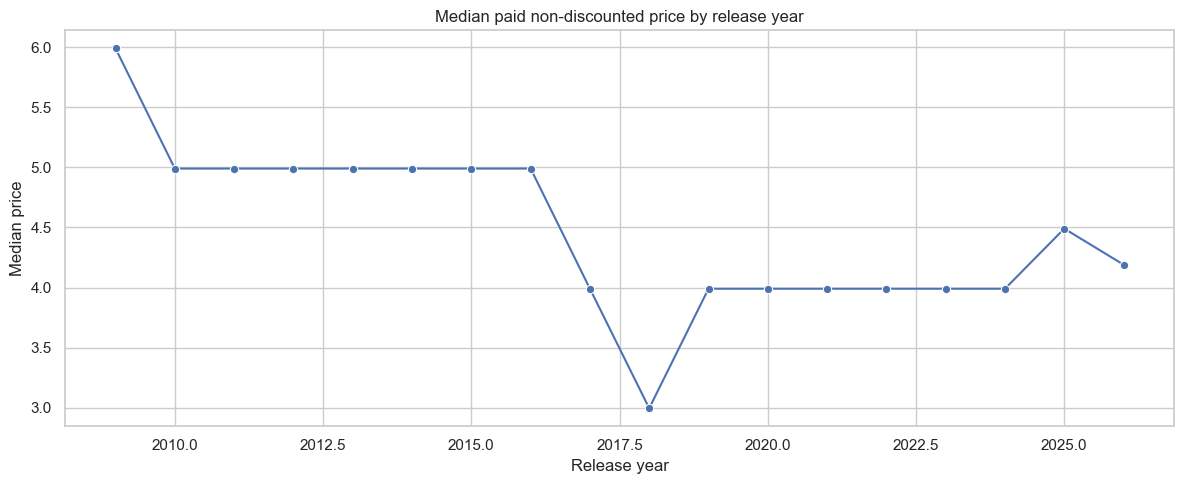

In [17]:
year_price = (
    analysis_df.dropna(subset=["Release year"])
    .assign(Release_year=lambda x: x["Release year"].astype(int))
    .groupby("Release_year")["Price"]
    .agg(game_count="size", median_price="median", mean_price="mean")
    .query("game_count >= 50")
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=year_price.reset_index(), x="Release_year", y="median_price", marker="o")
plt.title("Median paid non-discounted price by release year")
plt.xlabel("Release year")
plt.ylabel("Median price")
plt.tight_layout()

year_price.tail(15)

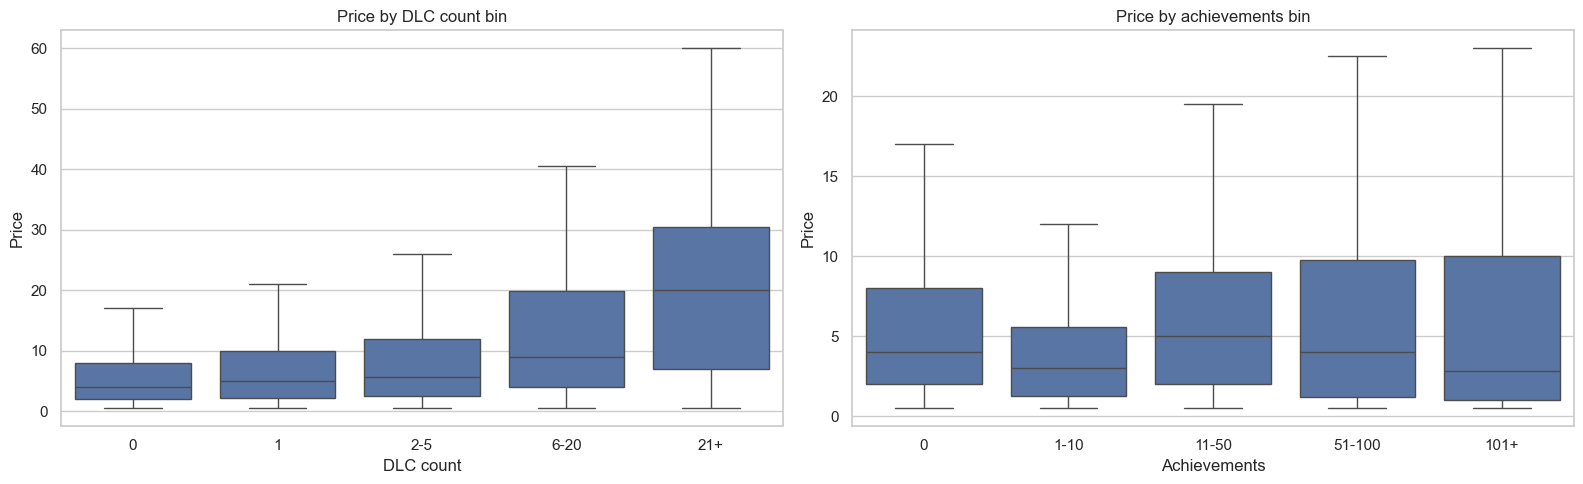

In [18]:
binned = analysis_df.copy()
binned["DLC count bin"] = pd.cut(binned["DLC count"].fillna(0), bins=[-1, 0, 1, 5, 20, np.inf], labels=["0", "1", "2-5", "6-20", "21+"])
binned["Achievements bin"] = pd.cut(binned["Achievements"].fillna(0), bins=[-1, 0, 10, 50, 100, np.inf], labels=["0", "1-10", "11-50", "51-100", "101+"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=binned, x="DLC count bin", y="Price", showfliers=False, ax=axes[0])
axes[0].set_title("Price by DLC count bin")
axes[0].set_xlabel("DLC count")

sns.boxplot(data=binned, x="Achievements bin", y="Price", showfliers=False, ax=axes[1])
axes[1].set_title("Price by achievements bin")
axes[1].set_xlabel("Achievements")

plt.tight_layout()

## 13. Post-release variables and leakage risk

Outcome variables are useful for gamer-facing value assessment, but they are not available to developers before launch. This section motivates keeping pre-release launch pricing and post-release player value as separate modeling tasks.



In [19]:
outcome_cols = [
    "Peak CCU",
    "Positive",
    "Negative",
    "Review count",
    "Positive share",
    "Recommendations",
    "Average playtime forever",
    "Median playtime forever",
    "Metacritic score",
]

corr_df = analysis_df[["Price"] + outcome_cols].copy()
for col in ["Price", "Peak CCU", "Positive", "Negative", "Review count", "Recommendations", "Average playtime forever", "Median playtime forever"]:
    corr_df[f"log1p_{col}"] = np.log1p(corr_df[col].fillna(0))

corr = corr_df.corr(numeric_only=True)[["Price", "log1p_Price"]].sort_values("log1p_Price", ascending=False)
corr

,Price,log1p_Price
log1p_Price,0.614117,1.000000
Price,1.000000,0.614117
log1p_Peak CCU,0.068454,0.157347
log1p_Recommendations,0.043611,0.132626
log1p_Average playtime forever,0.035284,0.126943
log1p_Median playtime forever,0.034475,0.126121
log1p_Negative,0.043351,0.104886
log1p_Review count,0.015251,0.085017
log1p_Positive,0.008113,0.082401
Metacritic score,0.019317,0.070611


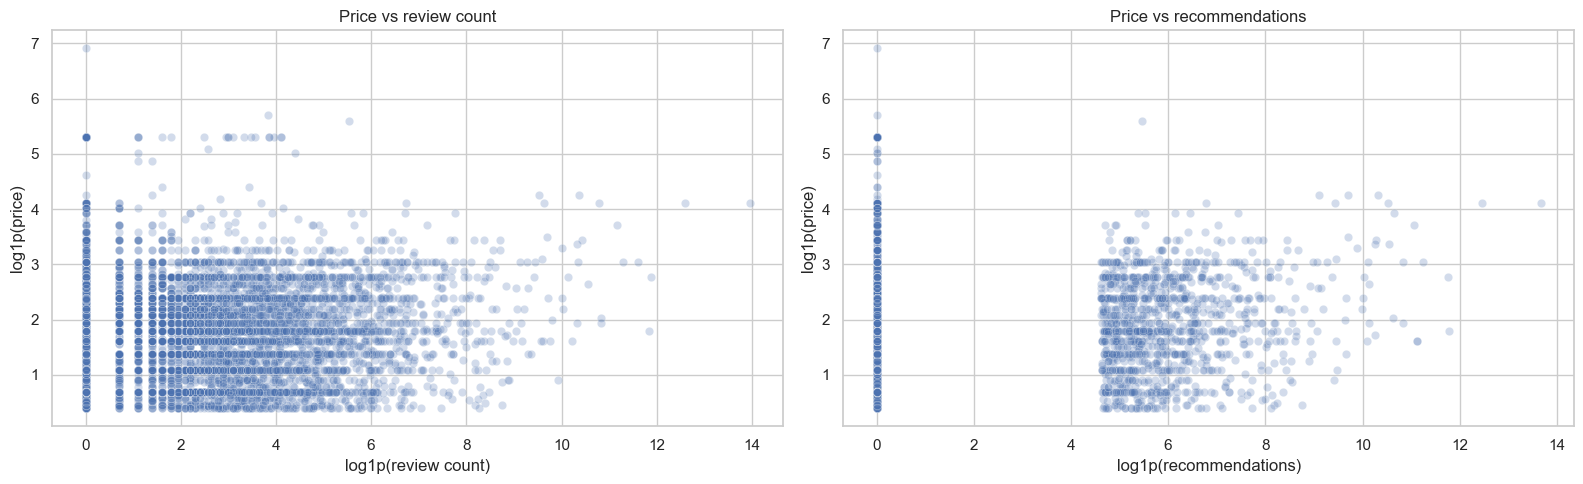

In [20]:
sample = analysis_df.sample(min(10000, len(analysis_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=sample, x=np.log1p(sample["Review count"].fillna(0)), y=np.log1p(sample["Price"]), alpha=0.25, ax=axes[0])
axes[0].set_title("Price vs review count")
axes[0].set_xlabel("log1p(review count)")
axes[0].set_ylabel("log1p(price)")

sns.scatterplot(data=sample, x=np.log1p(sample["Recommendations"].fillna(0)), y=np.log1p(sample["Price"]), alpha=0.25, ax=axes[1])
axes[1].set_title("Price vs recommendations")
axes[1].set_xlabel("log1p(recommendations)")
axes[1].set_ylabel("log1p(price)")

plt.tight_layout()

## 14. Comparable-game sanity checks

Before building KNN comparables, inspect whether the metadata fields contain enough signal to group similar games in a useful way.



In [21]:
def search_games(query, limit=20):
    mask = df["Name"].fillna("").str.contains(query, case=False, regex=False)
    cols = ["AppID", "Name", "Price", "Discount", "Genres", "Categories", "Tags", "Release year", "Recommendations"]
    return df.loc[mask, cols].sort_values(["Recommendations", "Price"], ascending=False).head(limit)


search_games("hades")

,AppID,Name,Price,Discount,Genres,Categories,Tags,Release year,Recommendations
70333,1145360,Hades,7.49,70,"Action,Indie,RPG","Single-player,Steam Achievements,Full controller support,Steam Trading Cards,Captions available,Steam Cloud,Remote Play on Phone,Remote ...","Action Roguelike,Rogue-lite,Hack and Slash,Indie,Mythology,Action,Rogue-like,Singleplayer,Great Soundtrack,Story Rich,RPG,Dungeon Crawle...",2020,271975
20861,1145350,Hades II,22.49,25,"Action,Indie,RPG","Single-player,Steam Achievements,Full controller support,Steam Trading Cards,Captions available,Steam Cloud,Family Sharing","Action,Rogue-like,Rogue-lite,Hack and Slash,RPG,Action Roguelike,Mythology,Dungeon Crawler,Action RPG,Isometric,Hand-drawn,Female Protag...",2025,99709
49280,1022310,Warhammer Underworlds - Shadespire Edition,2.99,90,"Casual,Strategy","Multi-player,PvP,Online PvP,Family Sharing","Turn-Based Tactics,Card Battler,Casual,Grand Strategy,Tactical RPG,Wargame,PvP,Competitive,Turn-Based,Board Game,Card Game,Tabletop,Turn...",2020,1048
46742,1399930,Furry Shades of Gay,2.09,70,"Casual,Indie,Strategy","Single-player,Steam Achievements,Steam Trading Cards,Steam Cloud,Family Sharing",,2020,791
70146,1724050,Furry Shades of Gay 2: A Shade Gayer,2.99,70,"Casual,Indie,Strategy","Single-player,Steam Achievements,Steam Trading Cards,Steam Cloud,Family Sharing",,2021,723
98474,1678140,Shades of Sakura,0.77,61,"Adventure,Casual,Indie,RPG","Single-player,Steam Achievements,Steam Trading Cards,Family Sharing","Hentai,Dating Sim,Mature,Puzzle,Visual Novel,NSFW,Casual,Anime,Indie,Adventure,Singleplayer,Sexual Content,Story Rich,RPG,Female Protago...",2021,527
115462,1953540,Furry Shades of Gay 3: Still Gayer,2.99,70,"Casual,Indie","Single-player,Steam Achievements,Steam Trading Cards,Steam Cloud,Family Sharing",,2023,370
42785,1932190,Outbreak: Shades of Horror,20.99,30,"Action,Adventure,RPG,Early Access","Single-player,Multi-player,Co-op,Online Co-op,Full controller support,Family Sharing",,2025,0
109425,653020,Lumins and Shades,14.99,0,"Casual,Indie,Strategy","Single-player,Steam Achievements,Full controller support,Family Sharing","Puzzle,Logic,Nonlinear,Exploration,Cute,Casual,Family Friendly,Pixel Graphics,2D,Strategy,Top-Down,Grid-Based Movement,Singleplayer,Atmo...",2023,0
46179,1532750,Jigsaw Pieces 2 - Shades of Mood,9.99,0,"Adventure,Casual,Indie","Single-player,Captions available,Stats,Family Sharing","Puzzle,Tabletop,2D,Cute,Adventure,Top-Down,Relaxing,Colorful,Realistic,Family Friendly,Logic,Nature,Old School,Singleplayer,Arcade,Puzzl...",2021,0


In [23]:
def item_set(row, columns=("Genres", "Categories", "Tags")):
    items = set()
    for col in columns:
        value = row.get(col)
        if pd.isna(value):
            continue
        items.update(part.strip() for part in str(value).split(",") if part.strip())
    return items


def rough_metadata_matches(app_id, limit=15):
    game = df.loc[df["AppID"].eq(app_id)].iloc[0]
    target_items = item_set(game)

    candidates = analysis_df[analysis_df["AppID"].ne(app_id)].copy()
    candidates["metadata_overlap"] = candidates.apply(lambda row: len(target_items & item_set(row)), axis=1)
    candidates["price_difference"] = candidates["Price"] - game["Price"]

    cols = ["AppID", "Name", "Price", "price_difference", "metadata_overlap", "Genres", "Tags", "Recommendations"]
    return candidates.sort_values(["metadata_overlap", "Recommendations"], ascending=False)[cols].head(limit)


# Replace this AppID after using search_games() above.
rough_metadata_matches(1145360)

,AppID,Name,Price,price_difference,metadata_overlap,Genres,Tags,Recommendations
53498,2126370,Wraithbinder,14.99,7.5,24,"Action,Indie,RPG,Early Access","Action Roguelike,Rogue-lite,Hack and Slash,Indie,Action,Rogue-like,Singleplayer,RPG,Story Rich,Dungeon Crawler,Replay Value,Isometric,Di...",0
64691,247080,Crypt of the NecroDancer,2.99,-4.5,19,"Action,Indie,RPG","Rhythm,Female Protagonist,Difficult,Rogue-like,Great Soundtrack,Pixel Graphics,Dungeon Crawler,Indie,Music,Local Co-Op,RPG,2D,Action,Rog...",23196
34750,1601740,Corpse Keeper,6.99,-0.5,19,"Action,Adventure,Indie,RPG,Strategy","Action RPG,Dark,Fantasy,Singleplayer,3D,Hack and Slash,Dungeon Crawler,Replay Value,Difficult,Strategy,Souls-like,Action Roguelike,Rogue...",1106
86309,1144910,Space Gladiators,14.99,7.5,19,"Action,Indie","Action,Indie,Rogue-lite,2D,2D Platformer,Hand-drawn,Action Roguelike,Difficult,Singleplayer,Perma Death,Side Scroller,Replay Value,Dunge...",412
10234,1646790,Striving for Light,13.49,6.0,19,"Action,Adventure,Casual,Indie,RPG","Early Access,Action RPG,Hack and Slash,Action Roguelike,Rogue-lite,RPG,Dungeon Crawler,Perma Death,Rogue-like,Action-Adventure,Procedura...",156
12993,266510,Hand of Fate,19.99,12.5,18,"Action,Indie,RPG","Roguelike Deckbuilder,Rogue-like,Deckbuilding,Card Game,Action Roguelike,RPG,Singleplayer,Action,Fantasy,Indie,Choose Your Own Adventure...",7958
100895,456670,Hand of Fate 2,29.99,22.5,18,"Action,Indie,RPG","RPG,Roguelike Deckbuilder,Card Game,Action,Deckbuilding,Rogue-lite,Indie,Action Roguelike,Singleplayer,Board Game,Fantasy,Rogue-like,Dun...",5207
4691,535480,Sundered®: Eldritch Edition,2.99,-4.5,18,"Action,Adventure,Indie","Roguevania,Metroidvania,Lovecraftian,Action Roguelike,Indie,Platformer,Hand-drawn,2D,Female Protagonist,Action,Difficult,Adventure,Side ...",4005
34330,1048350,Nigate Tale,4.99,-2.5,18,"Action,Adventure,Indie,RPG","Action Roguelike,Magic,Indie,Hack and Slash,Action,Rogue-like,Singleplayer,Rogue-lite,Action RPG,Cute,Story Rich,Anime,Dungeon Crawler,D...",660
48489,2549380,Cryptical Path,14.99,7.5,18,"Action,Indie,RPG","Action Roguelike,Hack and Slash,Rogue-like,Combat,Story Rich,Procedural Generation,Action,Difficult,Dark Humor,2D Platformer,3D,Rogue-li...",130


## 15. EDA decisions for later notebooks

The EDA supports the following modeling decisions:

- Main target: estimated list price, modeled as `log_list_price` after feature engineering.
- Discount handling: reconstruct list price from discounted rows when `0 < Discount < 100`; exclude free games, `Discount == 100`, and extreme prices above `$100`.
- Pre-release model: use metadata available before launch, especially genres, tags, categories, platforms, age rating, DLC count, achievements, and release timing.
- Post-release value model: add review count, positive share, recommendations, CCU, playtime, and Metacritic only after launch.
- Market scope: test full valid data first, then compare filtered scopes; the later notebooks use `review_count >= 10` as the practical default because it removes zero-traction games while preserving broad coverage.
- Primary metric: report MAE in dollars because the product question is the size of the pricing miss; keep median AE, RMSE, and within-threshold rates as supporting diagnostics.
- Modeling path: compare a median baseline, Ridge, KNN comparable-game pricing, and a boosted model improvement.

